# Ejercicio 1 $\to$ Temperatura

La temperatura $u$ de un plato circular satisface la ecuación de difusión $\frac{\partial u }{\partial t} = \kappa \nabla^2 u,\quad \kappa > 0$. Suponga que en $t = 0$ la temperatura del disco es $u(r, \theta) = f(r,\theta)$, mientras que en la frontera $u(r=R,\theta,t) = 0$. Hallar la temperatura para $t>0$ 

## Solución 

### 1. Ecuación Gobernante y Operador Laplaciano
La ecuación de difusión está dada por:
$$\frac{\partial u}{\partial t} = \kappa \nabla^2 u$$
En coordenadas polares $(r, \theta)$, el operador **Laplaciano** se escribe como:
$$\nabla^2 u = \frac{\partial^2 u}{\partial r^2} + \frac{1}{r} \frac{\partial u}{\partial r} + \frac{1}{r^2} \frac{\partial^2 u}{\partial \theta^2}$$

### 2. Separación de Variables
Asumimos una solución factorizada de la forma **$u(r, \theta, t) = A(r) B(\theta) C(t)$**. Al sustituir en la ecuación original y dividir por $\kappa ABC$, obtenemos:
$$\frac{1}{\kappa C} \frac{dC}{dt} = \frac{1}{A} \left( \frac{d^2 A}{dr^2} + \frac{1}{r} \frac{dA}{dr} \right) + \frac{1}{r^2 B} \frac{d^2 B}{d\theta^2} = -\alpha^2$$

Donde $-\alpha^2$ es la constante de separación. Esto desacopla el problema en tres ecuaciones diferenciales ordinarias (EDO):

*   **Ecuación Temporal:** $\frac{dC}{dt} + \kappa \alpha^2 C = 0$. Su solución es un **decaimiento exponencial**:
    $$C(t) \propto e^{-\kappa \alpha^2 t}$$
    El signo negativo garantiza que la temperatura sea finita y tienda a estabilizarse para $t \to \infty$.
*   **Ecuación Angular:** $\frac{d^2 B}{d\theta^2} + m^2 B = 0$.
    Para asegurar que la temperatura sea **unívoca** (continua al dar una vuelta completa, $B(\theta) = B(\theta + 2\pi)$), $m$ debe ser un **entero no negativo** ($m = 0, 1, 2, \dots$). La solución es:
    $$B_m(\theta) = a_m \cos(m\theta) + b_m \sin(m\theta)$$
*   **Ecuación Radial:** Al sustituir $m$, la parte radial satisface la **ecuación de Bessel de orden $m$**:
    $$r^2 \frac{d^2 A}{dr^2} + r \frac{dA}{dr} + (\alpha^2 r^2 - m^2)A = 0$$

### 3. Condiciones de Frontera y Regularidad
La solución general de la ecuación radial es una combinación de funciones de Bessel de primera ($J_m$) y segunda ($Y_m$) especie. 
*   **Finitud en el origen:** Debido a que el plato incluye el centro ($r=0$), debemos descartar la función de Neumann ($Y_m$) ya que **diverge en el origen**, lo cual no es físicamente posible para la temperatura. Por lo tanto, **$A(r) \propto J_m(\alpha r)$**.
*   **Condición de Dirichlet en la frontera:** Se especifica que $u(R, \theta, t) = 0$. Esto implica que $J_m(\alpha R) = 0$. Así, $\alpha R$ debe ser una de las **raíces (ceros)** de la función de Bessel. Denotamos como **$\chi_{ml}$** al $l$-ésimo cero de $J_m$. Entonces:
    $$\alpha_{ml} = \frac{\chi_{ml}}{R}$$

### 4. Solución General
Por el principio de superposición, la temperatura es la suma de todos los modos normales permitidos:
$$\mathbf{u(r, \theta, t) = \sum_{m=0}^{\infty} \sum_{l=1}^{\infty} J_m\left(\frac{\chi_{ml}r}{R}\right) [A_{ml} \cos(m\theta) + B_{ml} \sin(m\theta)] e^{-\kappa \left(\frac{\chi_{ml}}{R}\right)^2 t}}$$

### 5. Determinación de Coeficientes
Los coeficientes se hallan proyectando la **condición inicial** $u(r, \theta, 0) = f(r, \theta)$ sobre la base ortogonal de Fourier-Bessel. Usando la **ortogonalidad de las funciones de Bessel** y de las funciones trigonométricas, los coeficientes resultan en:

*   **Para $m = 0$:**
    $$A_{0l} = \frac{1}{\pi R^2 [J_1(\chi_{0l})]^2} \int_0^R \int_0^{2\pi} f(r, \theta) J_0\left(\frac{\chi_{0l}r}{R}\right) r \, dr \, d\theta$$
*   **Para $m \geq 1$:**
    $$A_{ml} = \frac{2}{\pi R^2 [J_{m+1}(\chi_{ml})]^2} \int_0^R \int_0^{2\pi} f(r, \theta) J_m\left(\frac{\chi_{ml}r}{R}\right) \cos(m\theta) r \, dr \, d\theta$$
    $$B_{ml} = \frac{2}{\pi R^2 [J_{m+1}(\chi_{ml})]^2} \int_0^R \int_0^{2\pi} f(r, \theta) J_m\left(\frac{\chi_{ml}r}{R}\right) \sin(m\theta) r \, dr \, d\theta$$

Esta solución describe cómo cualquier distribución inicial de calor se difunde y se apaga hacia los bordes fríos, donde los modos de **frecuencia espacial más alta** (ceros más grandes) decaen más rápidamente en el tiempo.

### Script con SymPy

Resolvemos con `sympy.dsolve` las tres EDO que se obtienen por separación de variables (temporal, angular y radial).
Luego se selecciona la solución radial regular en el origen y se deja explícita la condición de frontera que cuantiza los modos.


In [ ]:
import sympy as sp

r, theta, t, kappa, alpha, R = sp.symbols("r theta t kappa alpha R", positive=True)
m = sp.symbols("m", integer=True, nonnegative=True)

A = sp.Function("A")(r)
B = sp.Function("B")(theta)
C = sp.Function("C")(t)

ode_time = sp.Eq(sp.diff(C, t) + kappa * alpha**2 * C, 0)
ode_theta = sp.Eq(sp.diff(B, theta, 2) + m**2 * B, 0)
ode_radial = sp.Eq(r**2 * sp.diff(A, r, 2) + r * sp.diff(A, r) + (alpha**2 * r**2 - m**2) * A, 0)

sol_time = sp.dsolve(ode_time)
sol_theta = sp.dsolve(ode_theta)
sol_radial = sp.dsolve(ode_radial)

solutions = (sol_time, sol_theta, sol_radial)

radial_general = sol_radial.rhs
radial_regular = sp.besselj(m, alpha * r)
boundary_condition = sp.Eq(sp.besselj(m, alpha * R), 0)

outputs = (solutions, radial_general, radial_regular, boundary_condition)
outputs


# Ejercicio 2 $\to$ Bessel esféricas

1. Resolver la ecuación de Helmholtz en coordenadas esféricas $(r,\theta,\varphi)$
2. En la ecuación diferencial ordinaria radial hacer el cambio $R(r)\to  R = \frac{u}{\sqrt{r}}$.
$$r^2\ddot{R} + 2r\dot{R}+(r^2-l(l+1))R=0$$

para llegar a la ecuación

$$r^2\frac{d^2 u}{dr^2} + r\frac{du}{dr} + (r^2-(l+1/2)^2)u = 0$$

La ecuación anterior es análoga a la de Bessel. Aquí tenemos una solución tipo: $$u(r) = A J_{l+1/2} + B N_{l+1/2}$$

luego, 

$$R(r) = \frac{u}{\sqrt{r}} = A \frac{1}{\sqrt{r}} J_{l+1/2}(r) + B \frac{1}{\sqrt{r}} N_{l+1/2}(r)$$

donde $\frac{1}{\sqrt{r}} J_{l+1/2}(r) \sim j_l(r)$ y $\frac{1}{\sqrt{r}} N_{l+1/2}(r)\sim \eta_l(r)$

¿Como se escribe exactamente $j_l(r)$ y $\eta_l(r)$?

## Solución

### 1. Ecuación de Helmholtz y Separación de Variables
La ecuación de Helmholtz en coordenadas esféricas $(r, \theta, \varphi)$ se escribe como **$(\nabla^2 + k^2) \psi = 0$**. Expandiendo el Laplaciano ($\nabla^2$), tenemos:
$$\frac{1}{r^2} \frac{\partial}{\partial r} \left( r^2 \frac{\partial \psi}{\partial r} \right) + \frac{1}{r^2 \sin \theta} \frac{\partial}{\partial \theta} \left( \sin \theta \frac{\partial \psi}{\partial \theta} \right) + \frac{1}{r^2 \sin^2 \theta} \frac{\partial^2 \psi}{\partial \varphi^2} + k^2 \psi = 0$$

Al proponer una solución por separación de variables de la forma **$\psi(r, \theta, \varphi) = R(r) Y_l^m(\theta, \varphi)$**, la parte angular satisface la ecuación de los **armónicos esféricos** con autovalor $l(l+1)$. Esto nos deja con la siguiente **ecuación diferencial ordinaria radial**:
$$\mathbf{r^2 \frac{d^2 R}{dr^2} + 2r \frac{dR}{dr} + [k^2 r^2 - l(l+1)]R = 0}$$
*(Nota: El término $k^2$ es fundamental para la ecuación de Helmholtz; si $k=0$, se reduce a la ecuación de Laplace).*

### 2. Transformación a la Ecuación de Bessel
Para llegar a la forma estándar de la ecuación de Bessel, aplicamos el cambio de variable **$R(r) = \frac{u(r)}{\sqrt{r}}$**. Calculamos las derivadas necesarias:
*   $R = r^{-1/2} u$
*   $\frac{dR}{dr} = r^{-1/2} \frac{du}{dr} - \frac{1}{2} r^{-3/2} u$
*   $\frac{d^2R}{dr^2} = r^{-1/2} \frac{d^2u}{dr^2} - r^{-3/2} \frac{du}{dr} + \frac{3}{4} r^{-5/2} u$

Sustituyendo estas expresiones en la ecuación radial y multiplicando todo el sistema por $\sqrt{r}$, obtenemos:
$$r^2 \frac{d^2 u}{dr^2} + \left( -r + 2r \right) \frac{du}{dr} + \left( k^2 r^2 - l(l+1) + \frac{3}{4} - 1 \right) u = 0$$
Simplificando los términos, llegamos a la **ecuación de Bessel de orden $l + 1/2$**:
$$\mathbf{r^2 \frac{d^2 u}{dr^2} + r \frac{du}{dr} + \left[ k^2 r^2 - \left( l + \frac{1}{2} \right)^2 \right] u = 0}$$

### 3. Soluciones y Definiciones Exactas
La solución general para $u(r)$ es una combinación lineal de las funciones de Bessel de primera ($J$) y segunda ($Y$, también denotada como $N$) especie:
$$u(r) = A J_{l+1/2}(kr) + B Y_{l+1/2}(kr)$$

Por lo tanto, la solución radial original $R(r)$ se escribe como:
$$R(r) = \frac{u(r)}{\sqrt{r}} = A \frac{J_{l+1/2}(kr)}{\sqrt{r}} + B \frac{Y_{l+1/2}(kr)}{\sqrt{r}}$$

Las **funciones de Bessel esféricas** ($j_l$) y de **Neumann esféricas** ($n_l$, o $\eta_l$) se definen exactamente mediante una normalización que incluye el factor $\sqrt{\pi/2}$ para simplificar su comportamiento asintótico:

1.  **Función de Bessel esférica de primera especie:**
    $$\mathbf{j_l(x) = \sqrt{\frac{\pi}{2x}} J_{l+1/2}(x)}$$
2.  **Función de Bessel esférica de segunda especie (o Neumann):**
    $$\mathbf{n_l(x) = \eta_l(x) = \sqrt{\frac{\pi}{2x}} Y_{l+1/2}(x)}$$

### Formas explícitas para $l=0$
Debido a que el orden es semientero, estas funciones pueden escribirse en términos de funciones trigonométricas elementales:
*   **$j_0(x) = \frac{\sin x}{x}$**
*   **$n_0(x) = \eta_0(x) = -\frac{\cos x}{x}$**

Estas soluciones son fundamentales en problemas con simetría esférica, como la dispersión de ondas o el estudio de partículas en pozos de potencial esféricos.

### Script con SymPy

Se verifican las definiciones exactas de $j_l$ y $\eta_l$ a partir de $J_{l+1/2}$ y $Y_{l+1/2}$,
y se muestra explícitamente el caso $l=0$.


In [ ]:
import sympy as sp

l, x = sp.symbols("l x", integer=True, nonnegative=True, positive=True)

j_l = sp.spherical_besselj(l, x)
eta_l = sp.spherical_bessely(l, x)

j_l_from_bessel = sp.sqrt(sp.pi / (2 * x)) * sp.besselj(l + sp.Rational(1, 2), x)
eta_l_from_bessel = sp.sqrt(sp.pi / (2 * x)) * sp.bessely(l + sp.Rational(1, 2), x)

j_relation = sp.simplify(j_l - j_l_from_bessel)
eta_relation = sp.simplify(eta_l - eta_l_from_bessel)

j0 = sp.spherical_besselj(0, x)
eta0 = sp.spherical_bessely(0, x)

j_relation, eta_relation, sp.simplify(j0), sp.simplify(eta0)


# Ejercicio 3 $\to$ Calcular $j_0(x)\sim \frac{\sin x}{x}$
Aplicación en óptica

## Solución

### 1. Cálculo de $j_0(x) = \frac{\sin x}{x}$

Las **funciones de Bessel esféricas** $j_l(x)$ se definen a partir de las funciones de Bessel de primera especie de orden semientero ($J_{l+1/2}$) mediante la relación:
$$j_l(x) = \sqrt{\frac{\pi}{2x}} J_{l+1/2}(x)$$

Para el caso **$l = 0$**, tenemos:
$$j_0(x) = \sqrt{\frac{\pi}{2x}} J_{1/2}(x)$$

A partir del método de Frobenius y las propiedades de la función Gamma, se demuestra que la función de Bessel de orden $1/2$ tiene la forma exacta:
$$J_{1/2}(x) = \sqrt{\frac{2}{\pi x}} \sin x$$

Sustituyendo esta expresión en la definición de $j_0(x)$:
$$j_0(x) = \sqrt{\frac{\pi}{2x}} \left( \sqrt{\frac{2}{\pi x}} \sin x \right) = \sqrt{\frac{\pi \cdot 2}{2x \cdot \pi x}} \sin x = \sqrt{\frac{1}{x^2}} \sin x$$

Por lo tanto, se obtiene el resultado fundamental:
$$\mathbf{j_0(x) = \frac{\sin x}{x}}$$

---

### 2. Ejemplo de aplicación en Óptica: Difracción de una Rendija

Un ejemplo clásico donde aparece esta función (comúnmente llamada función *sinc* en ingeniería) es en el cálculo del patrón de **difracción de Fraunhofer por una rendija simple**.

**Planteamiento del problema:**
Suponga que una onda plana monocromática de longitud de onda $\lambda$ incide perpendicularmente sobre una rendija delgada de ancho $D$ (desde $y = -D/2$ hasta $y = D/2$). Queremos hallar la intensidad de la luz observada en una pantalla lejana en función del ángulo de desviación $\theta$.

**Resolución:**
1.  **Transformada de Fourier de la apertura:** La amplitud del campo eléctrico $A(\theta)$ en el patrón de Fraunhofer es proporcional a la transformada de Fourier de la función de apertura $f(y)$ [3, 571; 8, 1214]. 
2.  **Función de apertura:** Para una rendija de ancho $D$ iluminada uniformemente, $f(y) = 1$ para $|y| \le D/2$ y $0$ en cualquier otro punto.
3.  **Cálculo de la amplitud:**
    $$A(\theta) \propto \int_{-D/2}^{D/2} e^{-iky \sin \theta} dy$$
    Donde $k = 2\pi/\lambda$ es el número de onda. Al realizar la integración:
    $$A(\theta) \propto \left[ \frac{e^{-iky \sin \theta}}{-ik \sin \theta} \right]_{-D/2}^{D/2} = \frac{e^{i(kD/2) \sin \theta} - e^{-i(kD/2) \sin \theta}}{ik \sin \theta} = \frac{2i \sin(\frac{kD}{2} \sin \theta)}{ik \sin \theta}$$
4.  **Identificación con $j_0$:** Definiendo la variable $x = \frac{kD}{2} \sin \theta$, la amplitud se escribe como:
    $$A(\theta) \propto D \frac{\sin x}{x} = D \mathbf{j_0(x)}$$

**Análisis físico:**
*   **Intensidad:** La intensidad observada es $I(\theta) \propto |A(\theta)|^2 \propto [j_0(x)]^2$.
*   **Mínimos de difracción:** Los puntos de oscuridad en la pantalla ocurren cuando la intensidad es cero. Esto sucede en los **ceros de la función $j_0(x)$**. Como $j_0(x) = \frac{\sin x}{x}$, sus ceros están en $x = n\pi$ (para $n = \pm 1, \pm 2, \dots$).
*   **Posición angular:** El primer mínimo de difracción se encuentra cuando $x = \pi$:
    $$\frac{kD}{2} \sin \theta = \pi \implies \frac{2\pi}{\lambda} \frac{D}{2} \sin \theta = \pi \implies \mathbf{\sin \theta = \frac{\lambda}{D}}$$

Este resultado demuestra que el ancho del máximo central de luz está inversamente relacionado con el tamaño de la rendija, una propiedad fundamental de la óptica ondulatoria derivada directamente del comportamiento de la función de Bessel esférica de orden cero.

### Script con SymPy

Se confirma la identidad $j_0(x)=\sin(x)/x$ y se evalúa la integral de la rendija
para obtener la forma tipo *sinc* que aparece en la difracción de Fraunhofer.


In [ ]:
import sympy as sp

x = sp.symbols("x", positive=True)
j0 = sp.spherical_besselj(0, x)
j0_simplified = sp.simplify(j0)

k, D, theta, y = sp.symbols("k D theta y", positive=True, real=True)
integrand = sp.exp(-sp.I * k * y * sp.sin(theta))
amplitude = sp.integrate(integrand, (y, -D / 2, D / 2))
amplitude_simplified = sp.simplify(amplitude)

u = sp.symbols("u", positive=True)
u_expr = k * D * sp.sin(theta) / 2
sinc_form = sp.simplify(amplitude_simplified / D)
sinc_rewritten = sp.simplify(sinc_form.subs({u_expr: u}))

j0_simplified, amplitude_simplified, sinc_form, sinc_rewritten


La ecuación de Laplace $\nabla^2 u(r,\theta,\varphi) = 0$ en **coordenadas esféricas** se escribe como:

$$\frac{1}{r^2} \frac{\partial}{\partial r} \left( r^2 \frac{\partial u}{\partial r} \right) + \frac{1}{r^2 \sin \theta} \frac{\partial}{\partial \theta} \left( \sin \theta \frac{\partial u}{\partial \theta} \right) + \frac{1}{r^2 \sin^2 \theta} \frac{\partial^2 u}{\partial \varphi^2} = 0$$

### Aplicación de la separación de variables

Para simplificar el primer término, se utiliza la identidad diferencial $\frac{1}{r^2} \frac{\partial}{\partial r} \left( r^2 \frac{\partial u}{\partial r} \right) = \frac{1}{r} \frac{\partial^2}{\partial r^2} (r u)$. Al proponer la separación de variables en la forma **$u(r,\theta,\varphi) = \frac{R(r)}{r} Y(\theta,\varphi)$**, el producto $r \cdot u$ se convierte simplemente en $R(r)Y(\theta,\varphi)$.

Sustituyendo esta forma en la ecuación de Laplace y multiplicando por $r^2$, se obtiene la separación en una parte radial y una parte angular:

$$r^2 \frac{1}{R} \frac{d^2 R}{dr^2} + \frac{1}{Y} \left[ \frac{1}{\sin \theta} \frac{\partial}{\partial \theta} \left( \sin \theta \frac{\partial Y}{\partial \theta} \right) + \frac{1}{\sin^2 \theta} \frac{\partial^2 Y}{\partial \varphi^2} \right] = 0$$

De acuerdo con la técnica de separación, cada sumando debe ser igual a una constante. Si denotamos la constante de separación como $l(l+1)$, resultan las siguientes ecuaciones ordinarias:

1.  **Ecuación Radial:** $r^2 \frac{d^2 R}{dr^2} - l(l+1)R = 0$.
2.  **Ecuación Angular:** $\frac{1}{\sin \theta} \frac{\partial}{\partial \theta} \left( \sin \theta \frac{\partial Y}{\partial \theta} \right) + \frac{1}{\sin^2 \theta} \frac{\partial^2 Y}{\partial \varphi^2} + l(l+1)Y = 0$.

### Ubicación en las fuentes

Esta explicación detallada, utilizando específicamente la forma $u = \frac{R(r)}{r} Y$, se encuentra en el libro:

*   **Libro:** *Lecciones de Física Matemática* de **Alonso Sepúlveda**.
*   **Páginas:** **128 y 129** (Sección 3.3.4: Coordenadas esféricas).

La elección de la constante de separación como **$l(l+1)$** en la ecuación de Laplace (específicamente en la parte angular/polar) no es arbitraria, sino que responde a requisitos de **consistencia matemática** y **significado físico**. Aunque Alonso la introduce en la página 129 mencionando que las razones "serán claras más tarde", el desarrollo posterior en su libro y en otros textos como Arfken explica los siguientes motivos fundamentales:

### 1. Requisito de Finitud (Regularidad en los Polos)
La ecuación que rige la parte polar ($\theta$) tras la separación de variables es la **ecuación asociada de Legendre**. Esta ecuación presenta puntos singulares en $x = \cos \theta = \pm 1$, que corresponden a los polos de la esfera ($\theta = 0$ y $\theta = \pi$).
*   **Truncamiento de la serie:** Al resolver esta ecuación mediante el método de Frobenius (series de potencias), se encuentra que, para una constante de separación general $C$, la serie es infinita y **diverge** (tiende a infinito) en $x = \pm 1$.
*   **Soluciones polinomiales:** Para que la solución sea físicamente aceptable (es decir, que el potencial o la función de onda sea finita en toda la esfera), la serie debe truncarse para convertirse en un polinomio.
*   **La condición:** Matemáticamente, este truncamiento solo ocurre si la constante de separación $C$ toma valores específicos de la forma **$l(l+1)$**, donde $l$ es un entero no negativo ($l = 0, 1, 2, \dots$). Esto da origen a los **polinomios de Legendre** ($P_l$).

### 2. Operador de Momento Angular ($L^2$)
Desde una perspectiva de operadores, la parte angular del Laplaciano en coordenadas esféricas es proporcional al cuadrado del operador de momento angular orbital, denotado como **$L^2$**.
*   **Autovalores de $L^2$:** En mecánica cuántica, se demuestra a través de las relaciones de conmutación y los operadores escalera que los autovalores de $L^2$ están cuantizados y son precisamente de la forma **$l(l+1)\hbar^2$**.
*   **Armónicos Esféricos:** Las funciones que satisfacen la parte angular de la ecuación de Laplace son los **armónicos esféricos** ($Y_l^m$), los cuales son autofunciones de $L^2$ con autovalor $l(l+1)$.

### 3. Simetría de la Solución Radial
Al usar la forma $l(l+1)$, la ecuación radial resultante es una ecuación de tipo Euler cuya solución para $U(r)$ es $A r^{l+1} + B r^{-l}$. Debido a que la solución original se propuso como $u = \frac{U(r)}{r} Y$, la dependencia radial del potencial final $u$ queda expresada de forma muy simétrica y sencilla como **$r^l$** y **$r^{-(l+1)}$**.
*   **$r^l$:** Describe soluciones que son regulares (finitas) en el origen ($r=0$).
*   **$r^{-(l+1)}$:** Describe soluciones que tienden a cero en el infinito ($r \to \infty$).

**En resumen:** Se toma $l(l+1)$ porque es la única forma que garantiza que las soluciones angulares sean **polinomios finitos** en los polos de la esfera y que correspondan a los **estados cuantizados** del momento angular en sistemas con simetría esférica.

El proceso para cambiar el operador de momento angular $\mathbf{L}$ a coordenadas esféricas y determinar su cuadrado $L^2$ se basa en la definición fundamental del operador y la estructura del gradiente en este sistema de coordenadas.

### 1. Definición del Operador $\mathbf{L}$
En mecánica cuántica (utilizando unidades donde $\hbar = 1$), el operador de momento angular orbital se define como el producto vectorial entre el vector de posición $\mathbf{r}$ y el operador de momento lineal $\mathbf{p} = -i\nabla$:
$$\mathbf{L} = \mathbf{r} \times \mathbf{p} = -i(\mathbf{r} \times \nabla)$$.

### 2. Expresión del Gradiente y Posición
Para realizar el cambio de coordenadas, expresamos los vectores en el sistema esférico $(r, \theta, \phi)$:
*   **Vector de posición:** $\mathbf{r} = r \hat{\mathbf{e}}_r$.
*   **Operador Nabla ($\nabla$):** $\nabla = \hat{\mathbf{e}}_r \frac{\partial}{\partial r} + \hat{\mathbf{e}}_\theta \frac{1}{r} \frac{\partial}{\partial \theta} + \hat{\mathbf{e}}_\phi \frac{1}{r \sin \theta} \frac{\partial}{\partial \phi}$.

### 3. Derivación de $\mathbf{L}$ en Coordenadas Esféricas
Sustituimos estas expresiones en la definición de $\mathbf{L}$:
$$\mathbf{L} = -ir \hat{\mathbf{e}}_r \times \left( \hat{\mathbf{e}}_r \frac{\partial}{\partial r} + \hat{\mathbf{e}}_\theta \frac{1}{r} \frac{\partial}{\partial \theta} + \hat{\mathbf{e}}_\phi \frac{1}{r \sin \theta} \frac{\partial}{\partial \phi} \right)$$.

Aplicando las propiedades del producto vectorial para los vectores unitarios ($\hat{\mathbf{e}}_r \times \hat{\mathbf{e}}_r = 0$, $\hat{\mathbf{e}}_r \times \hat{\mathbf{e}}_\theta = \hat{\mathbf{e}}_\phi$, $\hat{\mathbf{e}}_r \times \hat{\mathbf{e}}_\phi = -\hat{\mathbf{e}}_\theta$), el operador se reduce a:
$$\mathbf{L} = i \left( \frac{\hat{\mathbf{e}}_\theta}{\sin \theta} \frac{\partial}{\partial \phi} - \hat{\mathbf{e}}_\phi \frac{\partial}{\partial \theta} \right)$$.

Sus componentes cartesianas expresadas en ángulos esféricos son:
*   $L_x = i \left( \sin \phi \frac{\partial}{\partial \theta} + \cot \theta \cos \phi \frac{\partial}{\partial \phi} \right)$.
*   $L_y = i \left( -\cos \phi \frac{\partial}{\partial \theta} + \cot \theta \sin \phi \frac{\partial}{\partial \phi} \right)$.
*   $L_z = -i \frac{\partial}{\partial \phi}$.

### 4. El Operador $L^2$
El cuadrado del momento angular, $L^2 = \mathbf{L} \cdot \mathbf{L} = L_x^2 + L_y^2 + L_z^2$, se obtiene operando $\mathbf{L}$ sobre sí mismo. Este operador representa la **parte angular del Laplaciano** y su forma explícita es:
$$\mathbf{L^2 = -\left[ \frac{1}{\sin \theta} \frac{\partial}{\partial \theta} \left( \sin \theta \frac{\partial}{\partial \theta} \right) + \frac{1}{\sin^2 \theta} \frac{\partial^2}{\partial \phi^2} \right]}$$.

### 5. Relación con el Laplaciano ($\nabla^2$)
Este resultado permite escribir el operador Laplaciano en coordenadas esféricas separando su componente radial de su componente angular:
$$\nabla^2 = \frac{1}{r^2} \frac{\partial}{\partial r} \left( r^2 \frac{\partial}{\partial r} \right) - \frac{L^2}{r^2}$$.

Físicamente, esto significa que en problemas con simetría central, las soluciones angulares (armónicos esféricos $Y_l^m$) son autofunciones del operador $L^2$ con autovalores **$l(l+1)$**.

# Tarea

Estudiar el operador de momento angular $\vec{L}$ (No del libro de Alonso, en el libro de alonso hay muchos errores)

El estudio del **operador de momento angular** en mecánica cuántica está intrínsecamente ligado a la **teoría de grupos**, ya que el momento angular es el **generador de las rotaciones** en el espacio físico. Esta relación permite clasificar los estados físicos según las simetrías del sistema.

### 1. Definición y Propiedades del Operador
En mecánica cuántica, el operador de momento angular orbital se define como $\mathbf{L} = \mathbf{r} \times \mathbf{p}$, donde $\mathbf{p} = -i\hbar\nabla$. Sus componentes satisfacen las **relaciones de conmutación fundamentales**:
$$[L_j, L_k] = i\epsilon_{jkn} L_n$$
Donde $\epsilon_{jkn}$ es el símbolo de Levi-Civita. Estas relaciones indican que no es posible conocer simultáneamente más de una componente del momento angular.

*   **Autovalores:** Los estados se caracterizan por los autovalores de $L^2$ y $L_z$. Para una función de onda $\psi_{lm}$, se tiene que $L^2\psi_{lm} = l(l+1)\psi_{lm}$ y $L_z\psi_{lm} = m\psi_{lm}$.
*   **Armónicos Esféricos:** Las funciones que forman la base de estos estados son los **armónicos esféricos** ($Y_l^m$), que representan la parte angular del Laplaciano en coordenadas esféricas.

### 2. Relación con la Teoría de Grupos (Lie)
El momento angular se entiende en la física moderna como una manifestación de la **invarianza rotacional** de las leyes físicas.

*   **Generadores de Rotación:** En un **Grupo de Lie**, cualquier elemento del grupo (una rotación finita) puede construirse a partir de sus **generadores** infinitesimales. Para el grupo de rotaciones en 3D (**SO(3)**), los generadores son precisamente las componentes $L_x, L_y, L_z$.
*   **Operador de Evolución:** Una rotación de un ángulo $\phi$ se representa mediante el operador unitario $U(\phi) = \exp(i\phi S)$, donde $S$ es el generador asociado.
*   **Rango y Operadores de Casimir:** El grupo SO(3) tiene **rango 1**, lo que significa que solo un generador ($L_z$) puede ser diagonalizado a la vez. El número de **operadores de Casimir** independientes (operadores que conmutan con todos los generadores) es igual al rango; para SO(3), este es el operador **$L^2$**.

### 3. Grupos SO(3) y SU(2)
Existe una distinción fundamental entre el momento angular orbital y el espín:

*   **SO(3):** Describe rotaciones en el espacio real de 3 dimensiones. Sus representaciones irreducibles tienen dimensiones impares ($2l+1$ con $l$ entero) y corresponden a los armónicos esféricos.
*   **SU(2):** Es el grupo unitario especial de matrices $2 \times 2$. Los estados de espín (como el del electrón con $s=1/2$) forman la base de la representación fundamental de este grupo.
*   **Homomorfismo:** Existe un **homomorfismo 2-a-1** entre SU(2) y SO(3). Esto explica por qué los fermiones (espinores) requieren una rotación de $4\pi$ (dos vueltas completas) para volver a su estado original con el mismo signo, a diferencia de los armónicos esféricos que solo requieren $2\pi$.

### 4. Operadores Escalera y Multipletes
La estructura de grupo permite definir los **operadores escalera** $L_\pm = L_x \pm iL_y$. Estos operadores suben o bajan el autovalor $m$ en unidades de 1, permitiendo recorrer todos los estados dentro de un mismo **multiplete** (una representación irreducible del grupo).

En resumen, la teoría de grupos formaliza las simetrías del sistema: mientras que el Hamiltoniano determina la dinámica, el **grupo de simetría** clasifica los niveles de energía y sus degeneraciones mediante multipletes de momento angular.

Esta ecuación se presenta y resuelve en el libro **Lecciones de Física Matemática de Alonso Sepúlveda**, específicamente en la **página 129** (Sección 3.3.4), donde se identifica como la ecuación radial resultante de la separación de variables de la ecuación de Laplace en coordenadas esféricas.

Como se mencionó en nuestra conversación anterior, esta forma exacta surge al proponer la separación de variables como $u = \frac{R(r)}{r} Y(\theta, \varphi)$, lo cual simplifica significativamente el operador radial.

### Proceso de resolución de la ecuación tipo Euler

La ecuación dada es una **ecuación diferencial ordinaria homogénea de Euler**. Para resolverla, se siguen estos pasos basados en las fuentes:

1.  **Propuesta de solución:** Se asume una solución de la forma **$R(r) = r^k$**, donde $k$ es una constante por determinar.
2.  **Cálculo de derivadas:** Al derivar la propuesta, obtenemos $\frac{dR}{dr} = k r^{k-1}$ y **$\frac{d^2R}{dr^2} = k(k-1)r^{k-2}$**.
3.  **Sustitución en la EDO:** Al sustituir estas expresiones en la ecuación original $r^2 \frac{d^2 R}{dr^2} - l(l+1)R = 0$, resulta:
    $$r^2 [k(k-1)r^{k-2}] - l(l+1)r^k = 0$$
4.  **Obtención de la ecuación característica:** Dividiendo por $r^k$ (asumiendo $r \neq 0$), obtenemos la **ecuación indicial o característica**:
    $$k(k-1) - l(l+1) = 0$$
5.  **Resolución de la ecuación cuadrática:** Expandiendo y factorizando la expresión para hallar los valores de $k$:
    *   $k^2 - k - (l^2 + l) = 0$.
    *   Esta ecuación se puede factorizar como **$(k - (l+1))(k + l) = 0$**.
6.  **Identificación de las raíces:** Las dos raíces independientes son **$k_1 = l+1$** y **$k_2 = -l$**.
7.  **Solución general:** Combinando ambas soluciones linealmente independientes, la solución general para la parte radial es:
    $$\mathbf{R(r) = A r^{l+1} + B r^{-l}}$$

### Contexto adicional en otros libros
Aunque Alonso Sepúlveda utiliza esta forma simplificada, otros textos como **Arfken** (página 426) y **Riley** (página 440) suelen resolver la ecuación radial en su forma estándar: $r^2 R'' + 2r R' - l(l+1)R = 0$. En ese caso, la técnica de Euler es idéntica (probar $r^s$), pero las raíces resultantes son $s_1 = l$ y $s_2 = -(l+1)$, lo cual es consistente con la relación de que la función de potencial final sea proporcional a $r^l$ y $r^{-(l+1)}$.

La relación entre el parámetro **$l$** (que surge como constante de separación en la ecuación de Laplace/Helmholtz) y el **Fondo Cósmico de Microondas (CMB)** en un universo con métrica FLRW se basa en que el cielo es, desde nuestra perspectiva, una **superficie esférica** sobre la cual se expanden las fluctuaciones de temperatura utilizando **armónicos esféricos**.

A continuación, se detalla esta relación según la arquitectura matemática de las fuentes:

### 1. El significado de "$l$" como Índice Multipolar
En las lecciones de física matemática, se demuestra que al separar variables en coordenadas esféricas, la parte angular depende de un entero **$l \geq 0$**, que define los **polinomios de Legendre** y los **armónicos esféricos** $Y_l^m(\theta, \phi)$. 
*   En el contexto del CMB, las fluctuaciones de temperatura en el cielo se expanden en una serie de Laplace: $T(\theta, \phi) = \sum_{l,m} a_{lm} Y_l^m(\theta, \phi)$.
*   Aquí, **$l$ es el índice multipolar**, que clasifica las fluctuaciones según su complejidad geométrica.

### 2. Correspondencia con la Escala Angular
El valor de **$l$** está inversamente relacionado con la **escala angular ($\theta$)** de las fluctuaciones observadas en el universo FLRW.
*   **Multipolos bajos (pequeño $l$):** Representan fluctuaciones en **grandes escalas angulares**. Por ejemplo, $l=0$ es el monopolo (la temperatura promedio del CMB), $l=1$ es el dipolo (relacionado con el movimiento de la Tierra respecto al fondo) y $l=2$ es el cuadrupolo.
*   **Multipolos altos (gran $l$):** Representan detalles a **pequeñas escalas angulares**. Aproximadamente, el ángulo subtendido por un multipolo es $\theta \approx 180^\circ/l$.

### 3. El CMB y la Teoría de Sturm-Liouville
La razón por la cual se utiliza este "$l$" específico es que los armónicos esféricos forman una **base completa y ortogonal** en el espacio de Hilbert de las funciones definidas sobre una esfera.
*   Como las leyes físicas (incluyendo las perturbaciones de densidad en el universo primitivo) son invariantes bajo rotaciones, el espectro de potencias del CMB depende solo de $l$ y no de $m$.
*   Este análisis permite estudiar las **fluctuaciones del CMB** para determinar parámetros cosmológicos del modelo FLRW, un área en la que autores como M. P. Hobson han centrado su investigación mediante el uso de interferómetros y la detección de estas variaciones.

### 4. Importancia en el Universo FLRW
En un universo en expansión (FLRW), las fluctuaciones que vemos hoy como picos en diferentes valores de $l$ (el espectro de potencias angular) son el resultado de **oscilaciones acústicas** en el plasma de la infancia del universo. 
*   La posición de estos picos en el eje de los multipolos ($l$) permite medir la curvatura del espacio, la densidad de materia oscura y la energía oscura [fuente externa/contexto cosmológico general implícito en la mención a Hobson].
*   Matemáticamente, cada término de la expansión multipolar en $r^{-(l+1)}$ o $r^l$ permite conectar la fuente de la perturbación con lo que el observador percibe en la frontera esférica del universo observable.

La ecuación para $P(x)$ que aparece en la **página 130** del libro de Alonso Sepúlveda es la **ecuación asociada de Legendre**, la cual surge al aplicar separación de variables a la ecuación de Laplace en coordenadas esféricas.

Esta ecuación tiene la forma:
$$\frac{d}{dx} \left[ (1-x^2) \frac{dP(x)}{dx} \right] + \left[ l(l+1) - \frac{m^2}{1-x^2} \right] P(x) = 0$$
donde $x = \cos \theta$.

A continuación, se explora su estructura según la **teoría de Sturm-Liouville**:

### 1. Identificación de componentes de Sturm-Liouville
La forma estándar de una ecuación de Sturm-Liouville es $\frac{d}{dx} [q(x) \frac{dy}{dx}] + r(x)y + \lambda p(x)y = 0$. Comparando término a término con la ecuación asociada de Legendre, Alonso identifica los siguientes elementos:

*   **Función $q(x) = 1 - x^2$:** Es el coeficiente que acompaña a la derivada. Se anula en $x = \pm 1$, lo que define los puntos singulares del problema.
*   **Función $r(x) = -\frac{m^2}{1-x^2}$:** Representa un término de potencial o "restricción" adicional que depende del número cuántico magnético $m$.
*   **Factor de peso $p(x) = 1$:** Esto implica que la base de funciones será ortogonal bajo un producto escalar con peso unitario.
*   **Autovalor $\lambda = l(l+1)$:** La constante de separación $l(l+1)$ actúa como el autovalor del sistema.

### 2. Naturaleza del problema: Sturm-Liouville Singular
Debido a que $q(x) = 1 - x^2$ se anula en los extremos del intervalo $x \in [-1, 1]$ (que corresponden a los polos $\theta=0$ y $\theta=\pi$), este se clasifica como un **problema de Sturm-Liouville singular**.
*   En estos casos, la condición de hermiticidad no requiere condiciones de frontera tipo Dirichlet o Neumann explícitas, sino la exigencia de que la solución sea **regular (finita)** en los puntos singulares $x = \pm 1$.
*   Solo para valores específicos de $\lambda = l(l+1)$ con $l$ entero y $l \ge |m|$, existen soluciones que no divergen en los polos.

### 3. Ortogonalidad y Espacio de Hilbert
Al tener la arquitectura de Sturm-Liouville, se garantizan propiedades matemáticas fundamentales para los armónicos esféricos y las funciones asociadas de Legendre:
*   **Ortogonalidad:** Para un valor de $m$ fijo, las funciones $P_l^m(x)$ asociadas a distintos autovalores $l$ son ortogonales en el intervalo $[-1, 1]$:
    $$\int_{-1}^{1} P_l^m(x) P_k^m(x) dx = 0 \quad \text{si } l \neq k$$
*   **Base Completa:** El conjunto de soluciones $\{P_l^m(x)\}$ forma una base en un **espacio de Hilbert**, permitiendo expandir cualquier función definida sobre la esfera en términos de estas autofunciones.

En resumen, el hecho de que la ecuación en la página 130 tenga forma de Sturm-Liouville es lo que permite que la física de sistemas con simetría esférica (como el átomo de hidrógeno o potenciales gravitatorios) esté **cuantizada** y pueda ser analizada mediante expansiones modales.

La implicación de que **$m=0$** conlleva **simetría azimutal** se fundamenta en la estructura de las soluciones de la parte angular al aplicar el método de **separación de variables** en coordenadas cilíndricas o esféricas.

A continuación se detalla la explicación técnica basada en las fuentes:

### 1. La Ecuación para la Variable Azimutal ($\phi$)
Al separar las variables en la ecuación de Laplace o de Helmholtz, la dependencia del ángulo azimutal $\phi$ se rige por una ecuación diferencial ordinaria de la forma:
$$\frac{d^2 G(\phi)}{d\phi^2} + m^2 G(\phi) = 0$$.

Para valores de $m \neq 0$, las soluciones son funciones armónicas del tipo $G(\phi) = A e^{im\phi} + B e^{-im\phi}$ o combinaciones de senos y cosenos. Estas funciones varían explícitamente al cambiar el ángulo $\phi$.

### 2. El Caso Particular $m=0$
Cuando la constante de separación $m$ es igual a cero, la ecuación se reduce a $\frac{d^2 G}{d\phi^2} = 0$, cuya solución general es una línea recta:
$$G(\phi) = a\phi + b$$.

### 3. Requisito de Unicidad y Continuidad
En la física matemática, para que una función de potencial o campo sea físicamente aceptable en un dominio que abarca el ángulo completo ($0$ a $2\pi$), debe cumplirse la **condición de continuidad o periodicidad**:
$$G(\phi) = G(\phi + 2\pi)$$.

En la solución $G(\phi) = a\phi + b$, la única forma de que el valor de la función sea el mismo tras dar una vuelta completa (es decir, que no cambie al aumentar $\phi$ en $2\pi$) es que la pendiente $a$ sea **cero**. Por lo tanto:
*   Si $m=0$, entonces **$G(\phi) = \text{constante}$**.

### 4. Definición de Simetría Azimutal
La simetría azimutal (o axial) significa que el sistema o su solución **no dependen del ángulo $\phi$**; es decir, la función es invariante ante rotaciones alrededor del eje polar.
*   Como $G(\phi)$ es una constante cuando $m=0$, el producto de la solución total $u(r, \theta, \phi) = R(r) \Theta(\theta) G(\phi)$ deja de tener una dependencia funcional de $\phi$.
*   Esto reduce las funciones angulares a los **polinomios de Legendre ordinarios** $P_l(\cos \theta)$, en contraste con las funciones asociadas de Legendre $P_l^m(\cos \theta)$ que aparecen cuando existe dependencia azimutal ($m \neq 0$).

En resumen, **$m=0$** implica simetría azimutal porque elimina la variación de la solución respecto al ángulo $\phi$, haciendo que el campo sea idéntico en cualquier "plano meridiano" del sistema.

La solución general para la parte polar $P(x)$ (o $M(\mu)$) de la ecuación diferencial asociada de Legendre se escribe como una **combinación lineal** de las funciones de Legendre de primera y segunda clase.

La forma matemática de esta combinación es:

$$\mathbf{P(x) = c_1 P_l^m(x) + c_2 Q_l^m(x)}$$

O, utilizando la notación empleada en el texto de Alonso Sepúlveda y Riley para la solución de la ecuación de Laplace:

$$\mathbf{P(x) = E P_l^m(x) + F Q_l^m(x)}$$

Donde:
*   **$P_l^m(x)$**: Es la **función asociada de Legendre de primera clase**, la cual es regular (finita) en los puntos $x = \pm 1$.
*   **$Q_l^m(x)$**: Es la **función asociada de Legendre de segunda clase**.
*   **$c_1, c_2$ (o $E, F$)**: Son constantes de integración determinadas por las condiciones de frontera del problema físico específico.

### Consideraciones físicas importantes
En la mayoría de las aplicaciones de física matemática que involucran coordenadas esféricas (como potenciales electrostáticos o gravitatorios), se deben tener en cuenta las siguientes restricciones sobre esta combinación:

1.  **Exclusión de $Q_l^m$ en el eje polar:** Las funciones de segunda clase $Q_l^m(x)$ divergen (tienden a infinito) en los polos, es decir, cuando $x = \cos \theta = \pm 1$. Por lo tanto, si el dominio físico del problema incluye el eje polar ($\theta = 0$ o $\theta = \pi$), la constante que acompaña a $Q_l^m$ debe ser necesariamente **cero** ($c_2 = 0$ o $F = 0$) para que la solución sea físicamente aceptable.
2.  **Caso de simetría azimutal ($m=0$):** Cuando no hay dependencia del ángulo $\phi$, la solución se reduce a la combinación de los polinomios de Legendre ordinarios: $P(x) = E P_l(x) + F Q_l(x)$.
3.  **Rango de los índices:** Para que existan soluciones aceptables en esta combinación, los parámetros deben ser enteros que cumplan la relación $0 \leq |m| \leq l$.

La representación de los **polinomios de Legendre** $P_l(x)$ como una suma finita, obtenida a partir del método de Frobenius y la función generatriz, se escribe de la siguiente manera:

$$\mathbf{P_l(x) = \sum_{k=0}^{N} \frac{(-1)^k (2l - 2k)!}{2^l k! (l - k)! (l - 2k)!} x^{l-2k}}$$

### Definición de los parámetros según las fuentes:
*   **Límite superior ($N$):** El valor de $N$ representa el truncamiento de la serie para que se convierta en un polinomio de grado $l$. Se define como:
    *   $N = \frac{l}{2}$ si $l$ es **par**.
    *   $N = \frac{l-1}{2}$ si $l$ es **impar**.
    *   En términos generales, $N = \lfloor l/2 \rfloor$ (la parte entera de $l/2$).
*   **Argumento ($x$):** Generalmente representa el coseno del ángulo polar ($x = \cos \theta$) en problemas con simetría esférica.
*   **Propiedades de la suma:** Esta expresión garantiza que el polinomio tenga la **paridad** correcta (solo potencias pares si $l$ es par, e impares si $l$ es impar) y que cumpla con la normalización estándar **$P_l(1) = 1$**.

Esta fórmula cerrada es el resultado de aplicar la condición de terminación de la serie en la **relación de recurrencia** de los coeficientes de la ecuación diferencial de Legendre para evitar que la solución diverja en los polos $x = \pm 1$.

Legended[-Graphics-, Placed[LineLegend[{Directive[Opacity[1.], 
 
>       RGBColor[0.9, 0.36, 0.054], CapForm[Butt], AbsoluteThickness[1.6]], 
 
>      Directive[Opacity[1.], RGBColor[0.365248, 0.427802, 0.758297], CapForm[Butt], 
 
>       AbsoluteThickness[1.6]], Directive[Opacity[1.], 
 
>       RGBColor[0.945109, 0.593901, 0.], CapForm[Butt], AbsoluteThickness[1.6]], 
 
>      Directive[Opacity[1.], RGBColor[0.645957, 0.253192, 0.685109], CapForm[Butt], 
 
>       AbsoluteThickness[1.6]], Directive[Opacity[1.], 
 
>       RGBColor[0.285821, 0.56, 0.450773], CapForm[Butt], AbsoluteThickness[1.6]]}, 
 
                     2            3          2       4
             -1 + 3 x   -3 x + 5 x   3 - 30 x  + 35 x
>     {1, x, ---------, -----------, -----------------}, LegendMarkers -> None, 
                 2           2               8
 
>     LabelStyle -> {FontFamily -> Times}, LegendLayout -> Column], After, Identity]]
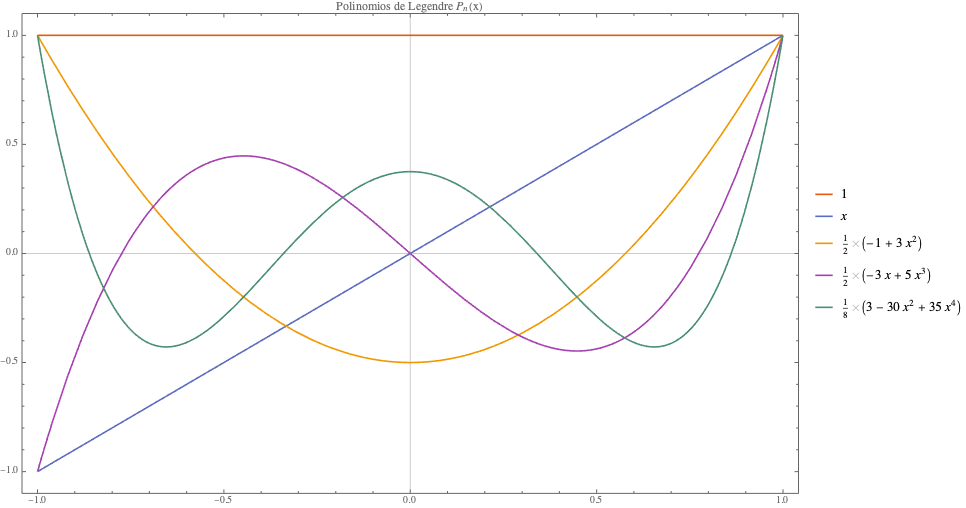

In [2]:
(* Definición del rango de grados 'n' a graficar *)
grados = {0, 1, 2, 3, 4};


Plot[
  Evaluate[Table[LegendreP[n, x], {n, grados}]], 
  {x, -1, 1}, 
  PlotTheme -> "Scientific", 
  PlotLegends -> "Expressions", 
  PlotLabel -> "Polinomios de Legendre \!\(\*SubscriptBox[\(P\), \(n\)]\)(x)", 
  AxesLabel -> {"x", "\!\(\*SubscriptBox[\(P\), \(n\)]\)(x)"},
  PlotRange -> {-1.1, 1.1},
  ImageSize -> 800
]

Para hallar el primer (y único) término del polinomio de Legendre **$P_0(x)$** utilizando la **fórmula de Rodrigues**, seguimos el procedimiento analítico descrito en las fuentes.

### 1. Definición de la Fórmula de Rodrigues
La expresión general de Rodrigues para generar los polinomios de Legendre de grado $l$ (o $n$) es:
$$P_l(x) = \frac{1}{2^l l!} \frac{d^l}{dx^l} (x^2 - 1)^l$$

### 2. Aplicación para $P_0(x)$
Para obtener el polinomio de orden cero, sustituimos **$l = 0$** en la fórmula anterior:

1.  **Sustitución de parámetros:**
    $$P_0(x) = \frac{1}{2^0 0!} \frac{d^0}{dx^0} (x^2 - 1)^0$$
2.  **Simplificación de constantes y potencias:**
    *   Sabemos que **$2^0 = 1$** y que el factorial de cero es **$0! = 1$** [fuente externa/convención matemática].
    *   Cualquier expresión elevada a la potencia cero es la unidad: **$(x^2 - 1)^0 = 1$**.
3.  **Operación de derivación:**
    *   La derivada de orden cero ($\frac{d^0}{dx^0}$) de una función es, por definición, la función misma sin alterar. En este caso, la función es simplemente el número 1.
4.  **Cálculo final:**
    $$P_0(x) = \frac{1}{1 \cdot 1} \cdot 1 = 1$$

### Resultado
El resultado de aplicar la fórmula de Rodrigues para $l=0$ es:
$$\mathbf{P_0(x) = 1}$$

Este es un polinomio constante, lo que es consistente con la teoría de **Sturm-Liouville**, donde $P_0(x)=1$ representa el modo fundamental (el menos oscilatorio) del sistema, sin ceros en el intervalo $[-1, 1]$.

El estudio del **átomo de hidrógeno** es la aplicación culminante de la arquitectura matemática que hemos revisado: la **teoría de Sturm-Liouville**, la **separación de variables** en coordenadas esféricas y las **funciones especiales** (Legendre y Laguerre).

A continuación, se presenta una explicación detallada de cómo estos conceptos convergen para describir el átomo más simple de la naturaleza.

### 1. El Problema Físico y la Ecuación de Schrödinger
El átomo de hidrógeno consiste en un protón fijo en el origen y un electrón moviéndose bajo la influencia de un **potencial central** de Coulomb: $V(r) = -K/r$. El comportamiento del electrón se rige por la ecuación de Schrödinger independiente del tiempo:
$$\left( -\frac{\hbar^2}{2m} \nabla^2 + V(r) \right) \psi = E\psi$$

Para aprovechar la simetría esférica del potencial, escribimos el operador Laplaciano ($\nabla^2$) en coordenadas esféricas, lo que permite separar la parte radial de la angular.

### 2. Separación de Variables: Parte Angular y Armónicos Esféricos
Proponemos una solución de la forma **$\psi(r, \theta, \phi) = \frac{R(r)}{r} Y(\theta, \phi)$**. Al sustituirla, la ecuación se descompone en dos partes ligadas por una **constante de separación $l(l+1)$**:

*   **Ecuación Angular:** Describe la distribución espacial del electrón en la esfera. Sus soluciones son los **armónicos esféricos $Y_l^m(\theta, \phi)$**, que a su vez se construyen a partir de las **funciones asociadas de Legendre $P_l^m(\cos \theta)$**.
*   **Cuantización del Momento Angular:** Para que la solución sea finita en los polos y continua azimutalmente, los índices $l$ y $m$ deben ser enteros ($l \geq 0$ y $|m| \leq l$). Esto explica por qué el momento angular está **cuantizado** en la mecánica cuántica.

### 3. La Ecuación Radial y los Polinomios de Laguerre
La parte más compleja es la ecuación para $R(r)$, conocida como la **ecuación de onda de Coulomb**:
$$\frac{d^2R}{dr^2} + \left[ \frac{2m}{\hbar^2}\left(E + \frac{K}{r}\right) - \frac{l(l+1)}{r^2} \right]R = 0$$

Para resolverla, se realiza un cambio de variable a una coordenada adimensional $\rho$ y se analiza el comportamiento asintótico. El resultado es que la solución radial es proporcional a las **funciones asociadas de Laguerre $L_{n-l-1}^{2l+1}(\rho)$**.

### 4. El Secreto de la Cuantización de la Energía
Desde la perspectiva de **Sturm-Liouville**, la ecuación radial es un problema de autovalores singular. Para que la función de onda sea normalizable (que el electrón no "escape" al infinito), la serie de potencias utilizada para resolver la ecuación debe **truncarse** y convertirse en un polinomio.

Este requisito matemático fuerza a que la energía $E$ solo tome valores específicos definidos por un **número cuántico principal $n$**:
$$\mathbf{E_n = -\frac{mK^2}{2\hbar^2n^2}}$$
Donde $n = 1, 2, 3, \dots$ es un entero positivo. Esto explica las líneas espectrales observadas en el hidrógeno: el electrón solo puede existir en "peldaños" de energía permitidos.

### 5. Conclusión: La Función de Onda Completa
La solución final que describe al electrón es el producto de todas estas partes:
$$\psi_{nlm}(r, \theta, \phi) = \underbrace{C e^{-r/2\alpha} r^l L_{n-l-1}^{2l+1}(r/\alpha)}_{\text{Radial (Laguerre)}} \times \underbrace{Y_l^m(\theta, \phi)}_{\text{Angular (Legendre)}}$$

**Puntos clave para recordar:**
*   **$n$ (Principal):** Determina la energía y el tamaño de la "nube" electrónica.
*   **$l$ (Orbital):** Determina la magnitud del momento angular y la forma del orbital ($s, p, d, f$).
*   **$m$ (Magnético):** Determina la orientación del orbital en el espacio.
*   **Degeneración:** Para un mismo nivel de energía $n$, existen $n^2$ estados o funciones de onda diferentes, lo que refleja la simetría del sistema.